Vérification de PySpark et impots 

In [4]:
import pyspark
print(pyspark.__version__) 

3.5.1


In [5]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import os, sys
from pyspark.sql.functions import count as spark_count, lit

In [6]:
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

spark = (SparkSession.builder
    .master("local[*]")
    .config("spark.driver.memory", "8g")
    .config("spark.executor.memory", "8g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate())

spark.sparkContext.setLogLevel("ERROR")
print("Spark démarré :", spark.version)

Spark démarré : 3.5.8


Chargement des données 

In [7]:
df = spark.read.parquet(r"C:\projet_spark\spark_project\audio_features.parquet")
rdd = df.rdd

print("Nombre de lignes :", rdd.count())
print("Exemple de ligne :", rdd.first())

Nombre de lignes : 8732
Exemple de ligne : Row(path='C:\\projet_spark\\spark_project\\Dataset_Sorted_by_class\\jackhammer\\165039-7-8-0.wav', duration=4.0, num_samples=88200, mfccs_mean=[-26.71396827697754, 90.76637268066406, 3.8246099948883057, 34.04445266723633, -6.0497565269470215, 17.523038864135742, 5.8503618240356445, 7.499879360198975, -7.637655735015869, 6.935105323791504, -2.2914459705352783, 7.557539463043213, -2.86669659614563], mfccs_std=[15.902982711791992, 5.532417297363281, 6.373729705810547, 3.882463216781616, 3.8862102031707764, 3.249758005142212, 5.194519996643066, 3.1950674057006836, 3.3101847171783447, 3.400137186050415, 3.726442337036133, 3.7250940799713135, 3.4683234691619873], spectral_centroid_mean=2401.7060546875, spectral_centroid_std=178.25303649902344, spectral_rolloff_mean=5388.27978515625, spectral_rolloff_std=270.7486267089844, zcr_mean=0.10607839375734329, zcr_std=0.019995536655187607, chroma_mean=[0.6849378347396851, 0.7853696346282959, 0.65812712907791

In [ ]:
counts = (
    rdd
    .map(lambda row: (row["label"], 1))
    .reduceByKey(lambda a, b: a+b)
    .sortBy(lambda x:x[0])
)

print("Fichiers par classe:")
for classe, count in counts.collect():
    print(f"classe {classe} : {count} fichiers")

Fichiers par classe:
classe air_conditioner : 1000 fichiers
classe car_horn : 429 fichiers
classe children_playing : 1000 fichiers
classe dog_bark : 1000 fichiers
classe drilling : 1000 fichiers
classe engine_idling : 1000 fichiers
classe gun_shot : 374 fichiers
classe jackhammer : 1000 fichiers
classe siren : 929 fichiers
classe street_music : 1000 fichiers


Aplatir les colonnes tableau - certines colonnes contiennent des tableaux. Spark ML a besosin de colonnes individuel donc on les explose 

In [18]:
# Les colonnes array et leur taille
array_cols = {
    "mfccs_mean": 13,
    "mfccs_std":  13,
    "chroma_mean": 12,
    "chroma_std":  12,
    "mel_spec_mean": 128, 
    "mel_spec_std":  128, 
}
scalar_features = [
    "spectral_centroid_mean", "spectral_centroid_std",
    "spectral_rolloff_mean",  "spectral_rolloff_std",
    "zcr_mean", "zcr_std",
    "rms_mean", "rms_std"
]
def aplatir_ligne(row):
    d = {}
    d["label"] = row["label"]

    for f in scalar_features:
        d[f] = row[f]
    for col_name, size in array_cols.items():
        for i in range(size):
            d[f"{col_name}_{i}"] = row[col_name][i]
    return d

rdd_flat = rdd.map(aplatir_ligne)

print("Exemple de ligne aplatie :", rdd_flat.first())
res = rdd_flat.first()

print(f"  Label : {res['label']}")
print(f"  Nb de clés : {len(res)}")
print(f"  mfccs_mean_0 : {res['mfccs_mean_0']}")

Exemple de ligne aplatie : {'label': 'jackhammer', 'spectral_centroid_mean': 2401.7060546875, 'spectral_centroid_std': 178.25303649902344, 'spectral_rolloff_mean': 5388.27978515625, 'spectral_rolloff_std': 270.7486267089844, 'zcr_mean': 0.10607839375734329, 'zcr_std': 0.019995536655187607, 'rms_mean': 0.17068174481391907, 'rms_std': 0.022367071360349655, 'mfccs_mean_0': -26.71396827697754, 'mfccs_mean_1': 90.76637268066406, 'mfccs_mean_2': 3.8246099948883057, 'mfccs_mean_3': 34.04445266723633, 'mfccs_mean_4': -6.0497565269470215, 'mfccs_mean_5': 17.523038864135742, 'mfccs_mean_6': 5.8503618240356445, 'mfccs_mean_7': 7.499879360198975, 'mfccs_mean_8': -7.637655735015869, 'mfccs_mean_9': 6.935105323791504, 'mfccs_mean_10': -2.2914459705352783, 'mfccs_mean_11': 7.557539463043213, 'mfccs_mean_12': -2.86669659614563, 'mfccs_std_0': 15.902982711791992, 'mfccs_std_1': 5.532417297363281, 'mfccs_std_2': 6.373729705810547, 'mfccs_std_3': 3.882463216781616, 'mfccs_std_4': 3.8862102031707764, 'mfc

Définir des features 

In [9]:
scalar_features = [
    "spectral_centroid_mean", "spectral_centroid_std",
    "spectral_rolloff_mean",  "spectral_rolloff_std",
    "zcr_mean", "zcr_std",
    "rms_mean", "rms_std"
]

array_features = []
for col_name, size in array_cols.items():
    for i in range(size):
        array_features.append(f"{col_name}_{i}")

all_features = scalar_features + array_features
print(f"Nombre total de features : {len(all_features)}")

Nombre total de features : 314


Split train/test

In [20]:
import random
random.seed(42)

def split_train_test(row):
    return "train" if random.random() < 0.8 else "test"

rdd_tagged = rdd_flat.map(lambda row: (split_train_test(row), row))

rdd_train = rdd_tagged.filter(lambda x: x[0] == "train").map(lambda x: x[1])
rdd_test = rdd_tagged.filter(lambda x: x[0] == "test").map(lambda x: x[1])  

print(f"Train : {rdd_train.count()} lignes")
print(f"Test  : {rdd_test.count()} lignes")

Train : 6964 lignes
Test  : 1729 lignes


Calcul des poids par classe avec RDD

In [21]:
# weight = total / (nb_classes × n_classe)

total = rdd_train.count()

classes_counts = (
    rdd_train
    .map(lambda row: (row["label"], 1))
    .reduceByKey(lambda a, b: a+b)
)
nb_classes = classes_counts.count()
poids_rdd = classes_counts.map(lambda x: (x[0], round(total / (nb_classes * x[1]), 4)))

poids_dict = dict(poids_rdd.collect()) # on convertit en dict python 
print("Poids par classe :")
for classe, poids in poids_dict.items():
    print(f"classe {classe} : poids {poids}")

Poids par classe :
classe jackhammer : poids 0.9077
classe drilling : poids 0.8712
classe children_playing : poids 0.869
classe dog_bark : poids 0.8488
classe air_conditioner : poids 0.8857
classe car_horn : poids 1.9732
classe gun_shot : poids 2.3558
classe siren : poids 0.9488
classe engine_idling : poids 0.8679
classe street_music : poids 0.8914


Créer le pipeline 

In [24]:
# on ajoute le poids a chaque ligne 
rdd_train_pondere = rdd_train.map(
    lambda row : {**row, "weight": poids_dict.get(row["label"], 1.0)}
)

# Conversion RDD -> DataFrame
train_df = spark.createDataFrame(rdd_train_pondere)
test_df  = spark.createDataFrame(rdd_test)

print(f"Train DataFrame : {train_df.count()} lignes")
print(f"Test DataFrame  : {test_df.count()} lignes")
train_df.select("label", "weight", "mfccs_mean_0").show(5)

Train DataFrame : 6937 lignes
Test DataFrame  : 1745 lignes
+----------+------+-------------------+
|     label|weight|       mfccs_mean_0|
+----------+------+-------------------+
|jackhammer|0.9077|  5.546497821807861|
|jackhammer|0.9077| -4.668474197387695|
|jackhammer|0.9077|-0.3107931315898895|
|jackhammer|0.9077| -96.01136779785156|
|jackhammer|0.9077| -93.97442626953125|
+----------+------+-------------------+
only showing top 5 rows



Pipeline Mlib

In [ ]:
#construction de la liste des features 
all_features = scalar_features + [
    f"{col_name}_{i}"
    for col_name, size in array_cols.items()
    for i in range(size)
]
label_indexer = StringIndexer(
    inputCol="label",        # colonne d'entrée : les noms de classes en texte ("dog_bark", "car_horn"...)
    outputCol="label_index", # colonne de sortie : les mêmes classes converties en nombres (0, 1, 2...)
    handleInvalid="keep"    
)

assembler = VectorAssembler(
    inputCols=all_features,  # toutes les colonnes de features 
    outputCol="features",    # colonne de sortie : un seul vecteur par ligne
    handleInvalid="keep"     # si une valeur est manquante ou nulle -> on la garde
)
rf = RandomForestClassifier(
    labelCol="label_index",          # colonne cible : les labels numériques créés par StringIndexer
    featuresCol="features",          # colonne d'entrée : le vecteur créé par VectorAssembler
    weightCol="weight",              # colonne de poids : pour rééquilibrer les classes sous-représentées
    numTrees=200,                    # nombre d'arbres dans la forêt (plus = plus précis, mais plus lent)
    maxDepth=10,                     # profondeur max de chaque arbre (évite le sur-apprentissage)
    minInstancesPerNode=3,           # un nœud ne se divise que s'il a au moins 3 exemples (régularisation)
    featureSubsetStrategy="sqrt",    # à chaque noeud, on teste seulement sqrt(nb_features) features au hasard
    seed=42                          # graine aléatoire -> résultats reproductibles à chaque exécution
)
pipeline = Pipeline(stages=[label_indexer, assembler, rf])
print("Pipeline créé !")

Pipeline créé !


Entrainement

In [26]:
print("Entraînement en cours...")

model = pipeline.fit(train_df)  

print("Entraînement terminé !")

Entraînement en cours...
Entraînement terminé !


Evaluation

In [27]:
predictions = model.transform(train_df)

evaluator_acc = MulticlassClassificationEvaluator(
    labelCol="label_index",
    predictionCol="prediction",
    metricName="accuracy"
)
accuracy = evaluator_acc.evaluate(predictions)

print(f"Accuracy : {accuracy * 100:.2f}%")

Accuracy : 92.24%


Matrice de confusion 

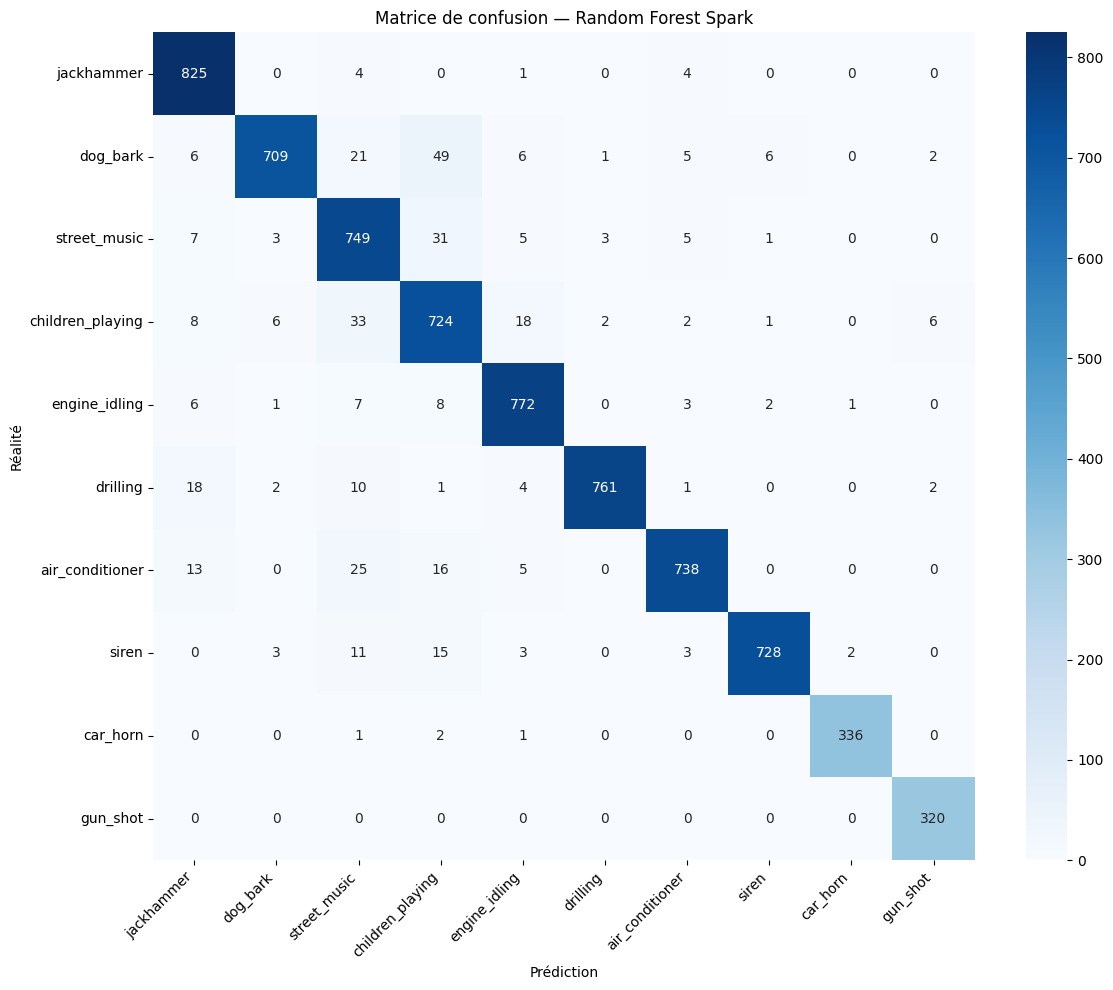

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

y_true = [row["label_index"] for row in predictions.select("label_index").collect()]
y_pred = [row["prediction"]   for row in predictions.select("prediction").collect()]

class_labels = model.stages[0].labels

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel("Prédiction")
plt.ylabel("Réalité")
plt.title("Matrice de confusion — Random Forest Spark")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [15]:
model.write().overwrite().save(r"C:\projet_spark\spark_project\rf_model")
print("Modèle sauvegardé")


Modèle sauvegardé
